<a href="https://colab.research.google.com/github/winwinjong-gif/Machin-Learning-report/blob/week2/wine_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Dataset EDA 실습

첨부된 iris_EDA의 실제 분석 셀 순서를 Wine 데이터에 적용합니다. EDA는 학습 전에 구조, 결측치, 분포, 변수 관계 등을 살펴보는 과정입니다.

출처: 사용자 제공 iris_EDA (1).ipynb 및 wine (1).csv. 원본 목차의 변동계수·분리도 항목에는 실제 코드 셀이 없어 추가하지 않았습니다.


## 1. 필요한 라이브러리 불러오기

pandas는 표 처리, NumPy는 수치 계산, Matplotlib과 Seaborn은 그래프에 사용합니다. whitegrid는 흰 배경의 격자 스타일입니다.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")

## 2. 데이터 불러오기

Colab에서는 파일 선택 창에서 wine (1).csv를 선택합니다. 로컬에서는 DATA_PATH를 사용합니다. index_col=0을 지정하면 Wine 레이블이 빠지므로 사용하지 않습니다.


In [ ]:
# Colab에서는 실행 후 첨부한 wine (1).csv 파일을 선택하세요.
# 로컬에서는 아래 DATA_PATH를 파일 경로로 지정하세요.
import sys
from pathlib import Path

DATA_PATH = Path("C:/Users/이종혁/Downloads/wine (1).csv")
if "google.colab" in sys.modules:
    from google.colab import files
    import io
    uploaded = files.upload()
    filename = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
else:
    df = pd.read_csv(DATA_PATH)

# Wine은 인덱스가 아니라 분류 레이블입니다.
display(df)


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


## 3. 데이터 구조 확인

EDA의 첫 단계는 데이터가 몇 개의 행과 열로 구성되어 있는지, 어떤 변수들이 존재하는지 확인하는 것입니다.

- `shape`: 행과 열의 개수
- `head()`: 처음 5개 행
- `columns`: 변수 이름
- `dtypes`: 각 변수의 자료형
- `info()`: 데이터 전체 구조 요약


In [ ]:
print("데이터 크기:", df.shape)

print("\n처음 5개 데이터")
display(df.head())

print("\n변수 이름")
print(df.columns.tolist())

print("\n자료형")
print(df.dtypes)

print("\n데이터 정보")
df.info()

데이터 크기: (178, 14)

처음 5개 데이터

변수 이름
['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

자료형
Wine                      int64
Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object

데이터 정보
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null 

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 4. 결측치와 중복 데이터 확인

결측치는 값이 비어 있는 데이터를 의미합니다. 결측치가 많으면 분석 결과에 영향을 줄 수 있으므로 반드시 확인해야 합니다.

중복 데이터는 동일한 관측값이 여러 번 존재하는 경우입니다. 중복 데이터가 많으면 특정 관측값이 분석 결과에 과도한 영향을 줄 수 있습니다.


In [ ]:
print("변수별 결측치 개수")
print(df.isnull().sum())

print("\n중복 행 개수")
print(df.duplicated().sum())

변수별 결측치 개수
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

중복 행 개수
0


## 5. 분석 변수 지정

입력은 13개 수치형 변수이고 레이블은 Wine입니다. Wine의 1·2·3은 종류를 나타내는 코드이며 품질 점수나 수량이 아닙니다. 범주형으로 지정해 그래프에서 구분합니다. 열 이름의 점(.)도 그대로 유지합니다.


In [ ]:
numeric_cols = ['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

target_col = "Wine"

# 숫자 1, 2, 3을 크기가 없는 범주로 지정합니다.
df[target_col] = df[target_col].astype("category")


## 6. 레이블 종류와 개수 확인

분류 문제에서는 각 레이블이 무엇인지, 그리고 각 레이블의 데이터 개수가 얼마나 되는지 확인하는 것이 중요합니다.

레이블별 데이터 수가 크게 차이 난다면 클래스 불균형 문제가 있을 수 있습니다.


In [ ]:
print("레이블 종류")
print(df[target_col].unique())

print("\n레이블별 개수")
print(df[target_col].value_counts())

레이블 종류
[1, 2, 3]
Categories (3, int64): [1, 2, 3]

레이블별 개수
Wine
2    71
1    59
3    48
Name: count, dtype: int64


In [ ]:
# 레이블 갯수 확인 (숫자)

df['Wine'].value_counts()

### 레이블 개수 시각화

`countplot`은 각 범주에 몇 개의 데이터가 존재하는지 막대그래프로 보여줍니다.

막대 위에 실제 데이터 개수도 함께 표시합니다.


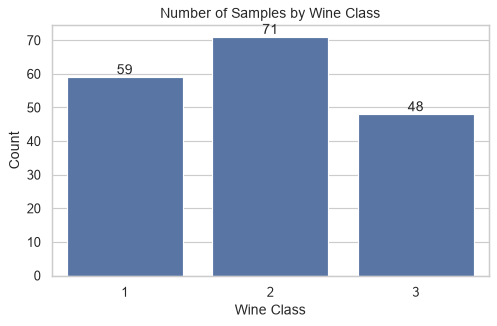

In [ ]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x=target_col
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Samples by Wine Class")
plt.xlabel("Wine Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 7. 기술통계량 확인

`describe()`는 수치형 변수의 기본적인 통계량을 보여줍니다.

- `count`: 데이터 개수
- `mean`: 평균
- `std`: 표준편차
- `min`: 최솟값
- `25%`: 1사분위수
- `50%`: 중앙값
- `75%`: 3사분위수
- `max`: 최댓값

이를 통해 데이터의 전체적인 범위와 분포를 빠르게 파악할 수 있습니다.


In [ ]:
display(df[numeric_cols].describe().round(3))

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


## 8. 와인 종류별 평균과 표준편차 확인

`groupby()`를 이용하면 데이터를 와인 종류별로 나누어 평균과 표준편차를 계산할 수 있습니다.

와인 종류별 평균 차이가 큰 변수는 와인 종류 구별에 유용할 가능성이 있습니다.


In [ ]:
print("와인 종류별 평균")
display(
    df.groupby(target_col, observed=True)[numeric_cols]
      .mean()
      .round(3)
)

print("와인 종류별 표준편차")
display(
    df.groupby(target_col, observed=True)[numeric_cols]
      .std()
      .round(3)
)

와인 종류별 평균
와인 종류별 표준편차


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Wine,,,,,,,,,,,,,
1,13.745,2.011,2.456,17.037,106.339,2.840,2.982,0.290,1.899,5.528,1.062,3.158,1115.712
2,12.279,1.933,2.245,20.238,94.549,2.259,2.081,0.364,1.630,3.087,1.056,2.785,519.507
3,13.154,3.334,2.437,21.417,99.312,1.679,0.781,0.448,1.154,7.396,0.683,1.684,629.896


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Wine,,,,,,,,,,,,,
1,0.462,0.689,0.227,2.546,10.499,0.339,0.397,0.070,0.412,1.239,0.116,0.357,221.521
2,0.538,1.016,0.315,3.350,16.753,0.545,0.706,0.124,0.602,0.925,0.203,0.497,157.211
3,0.530,1.088,0.185,2.258,10.890,0.357,0.294,0.124,0.409,2.311,0.114,0.272,115.097


## 9. 각 변수의 전체 분포 확인

히스토그램은 값이 어느 구간에 많이 존재하는지 보여줍니다.

`kde=True`를 사용하면 데이터 분포를 부드러운 밀도 곡선으로 함께 표시할 수 있습니다.


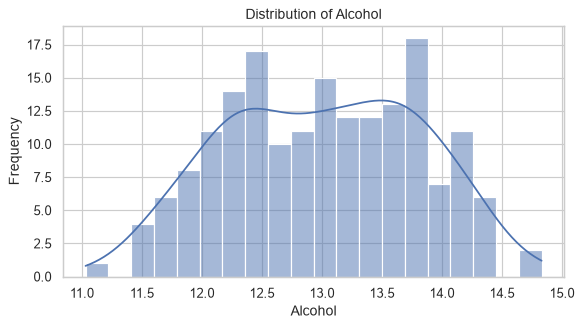

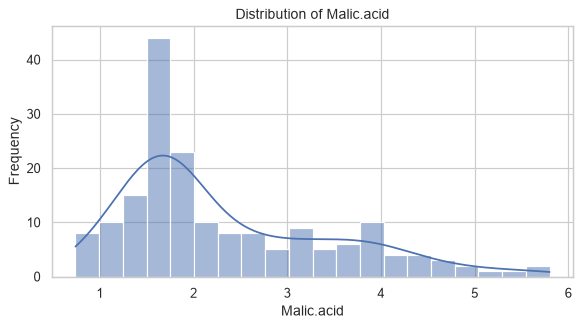

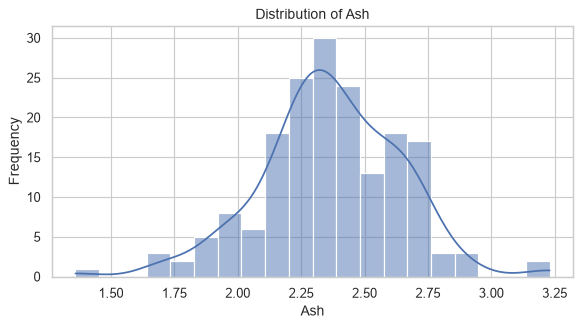

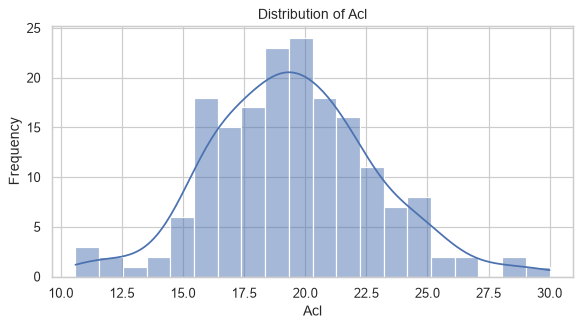

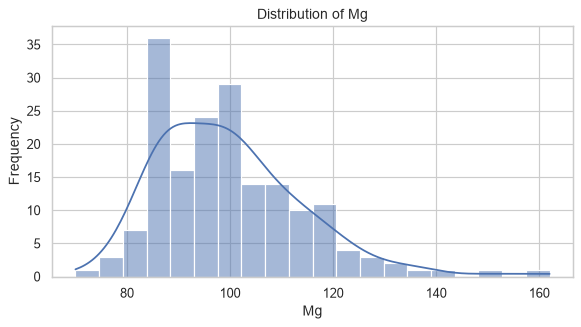

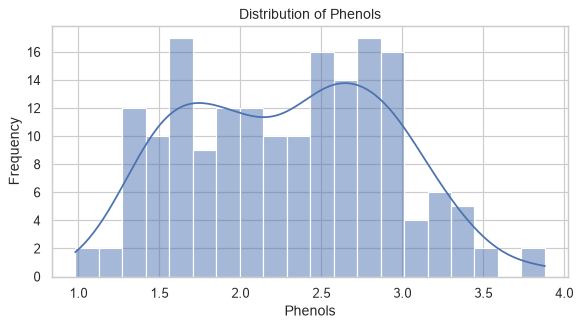

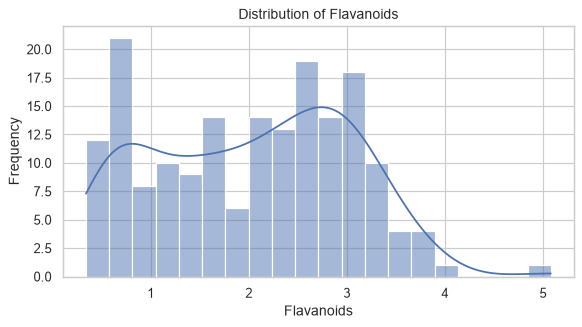

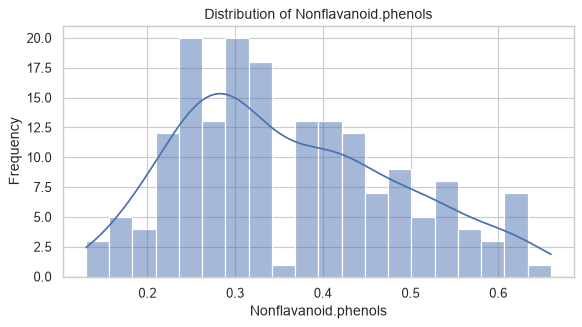

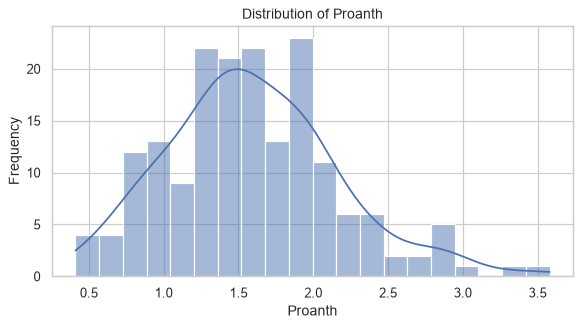

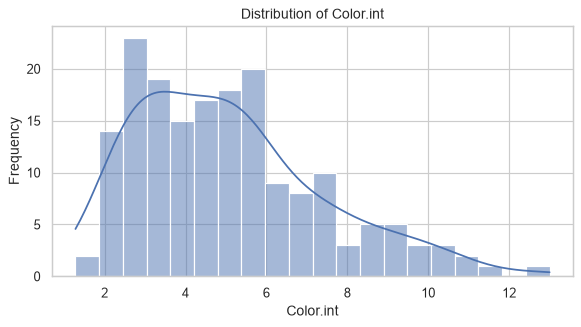

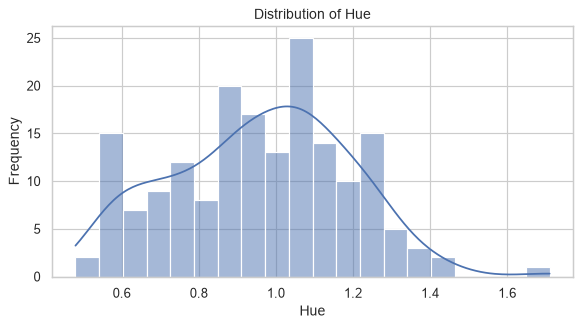

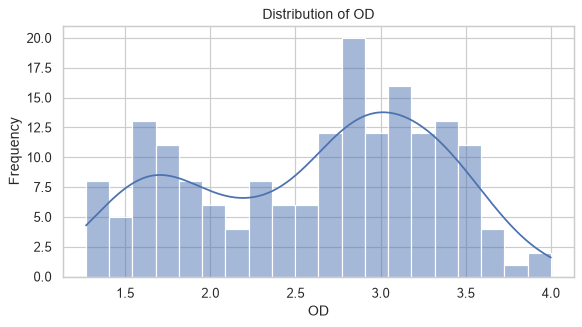

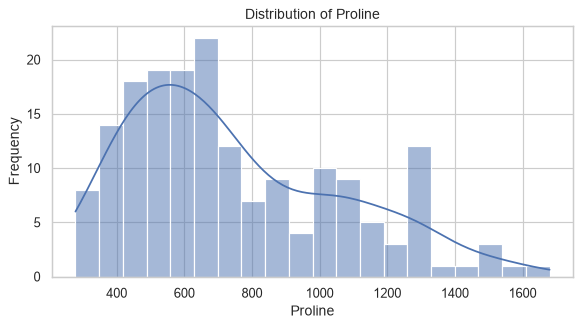

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## 10. 와인 종류별 변수 분포 비교

hue는 종류별 색을 지정합니다. stat="density"와 common_norm=False는 종류별 면적을 각각 1로 맞춰 개수가 다른 집단의 분포 모양을 비교합니다. 겹침이 적으면 분류에 유용할 가능성이 있습니다.


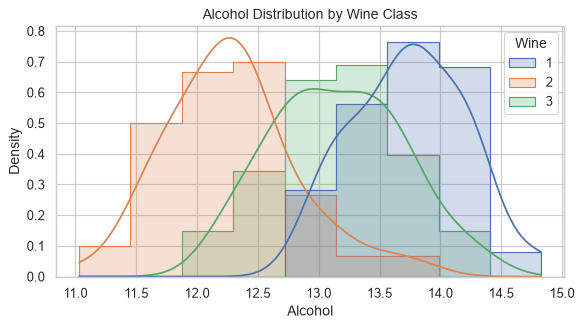

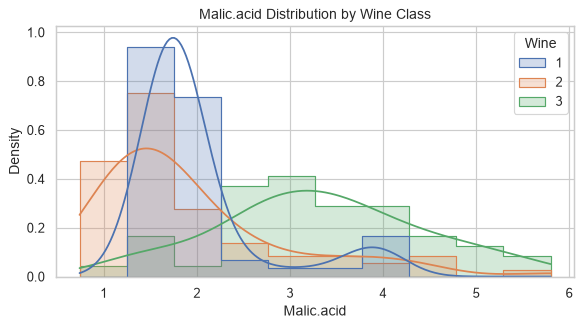

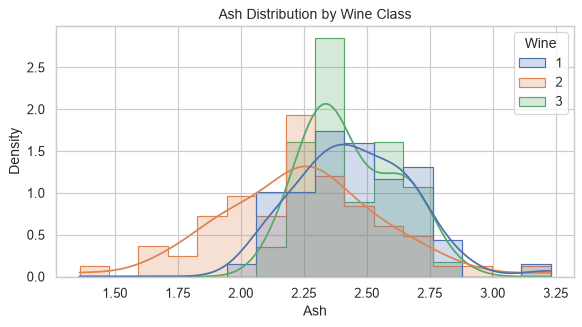

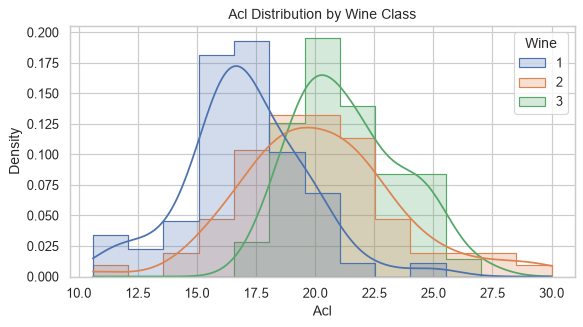

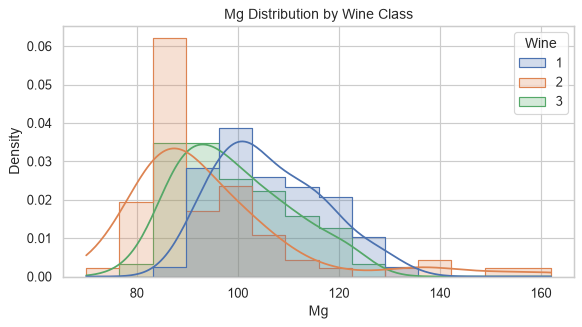

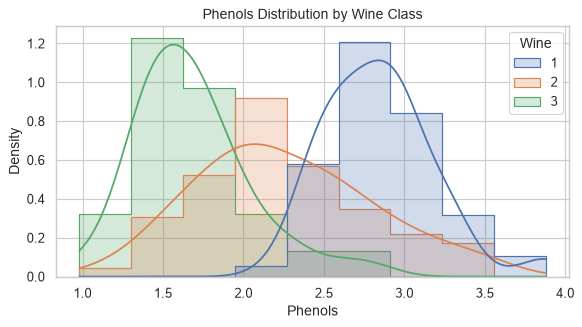

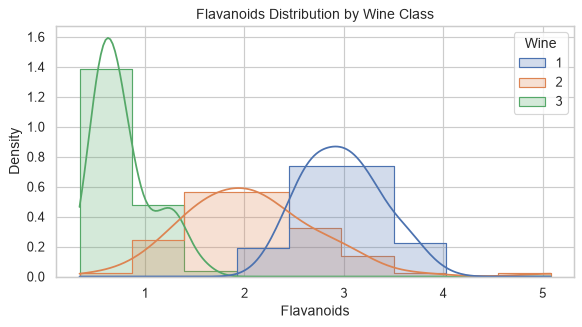

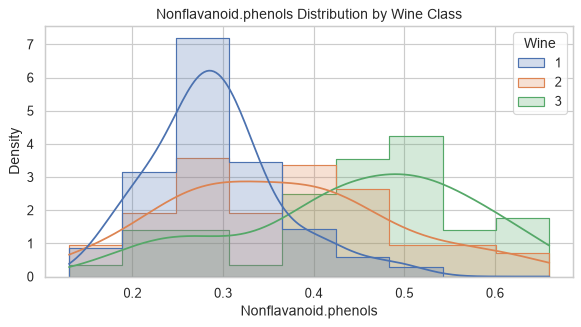

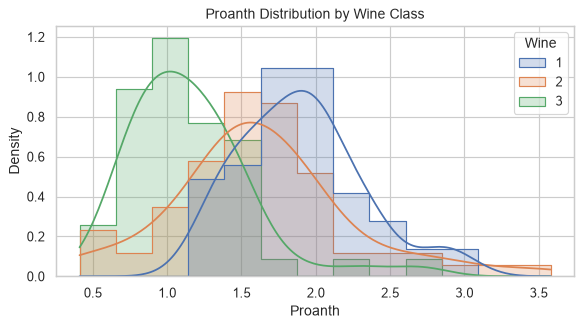

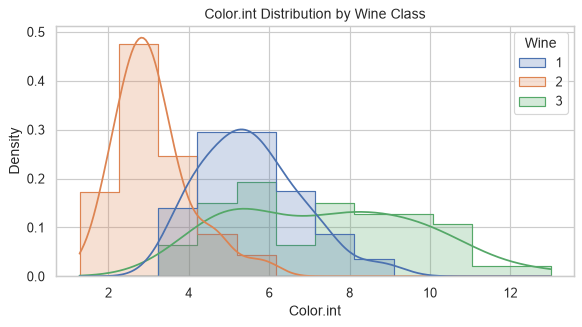

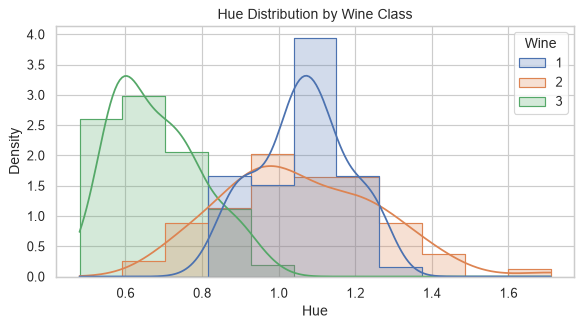

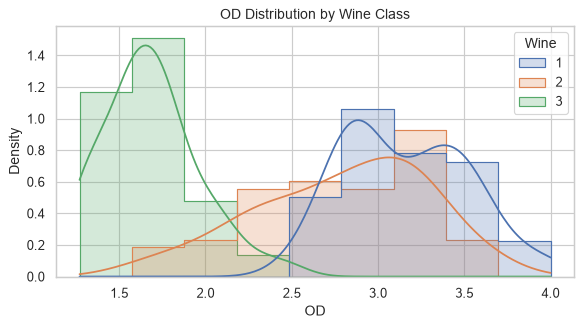

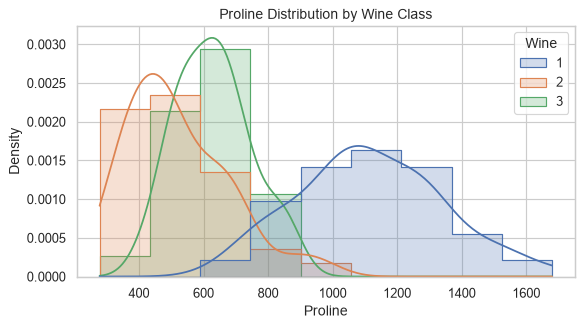

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"{col} Distribution by Wine Class")

    plt.tight_layout()
    plt.show()

## 11. Box Plot

Box Plot은 중앙값, 사분위수, 데이터 범위, 이상치 등을 한 번에 확인할 수 있습니다.

와인 종류별 중앙값과 분포 범위를 비교하면 각 변수에서 와인 종류 차이가 얼마나 큰지 확인할 수 있습니다.


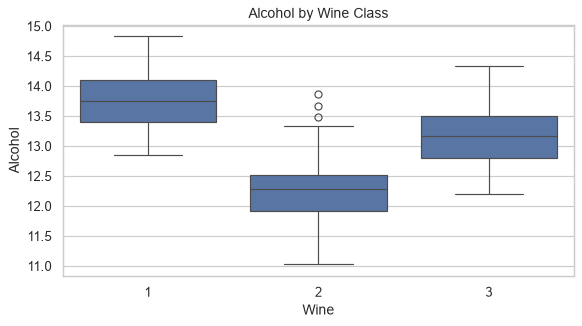

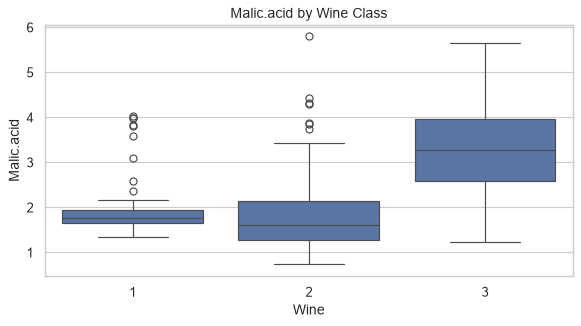

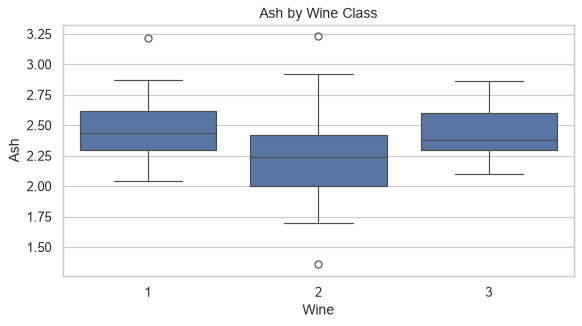

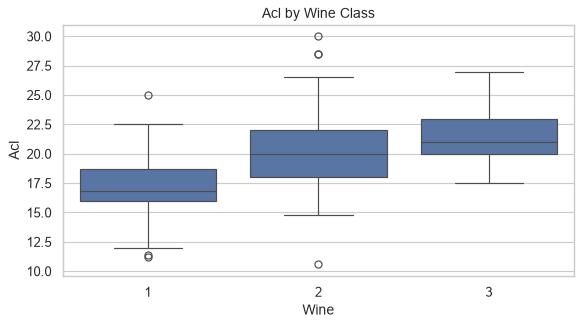

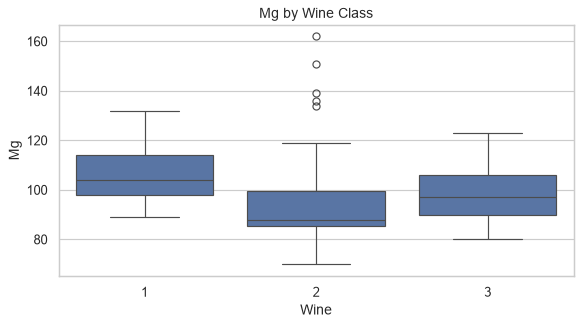

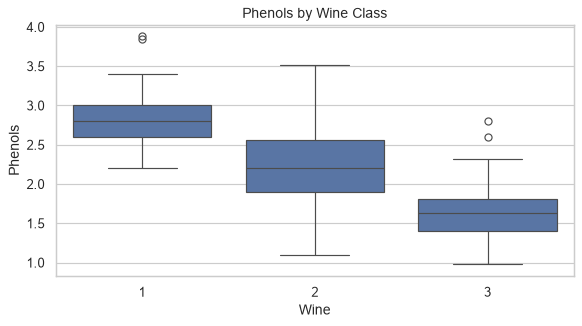

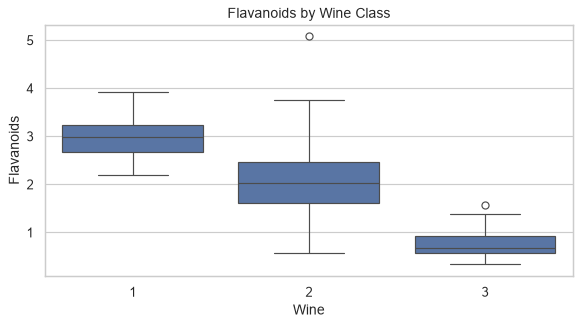

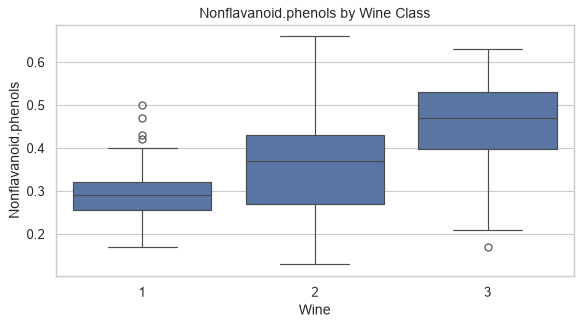

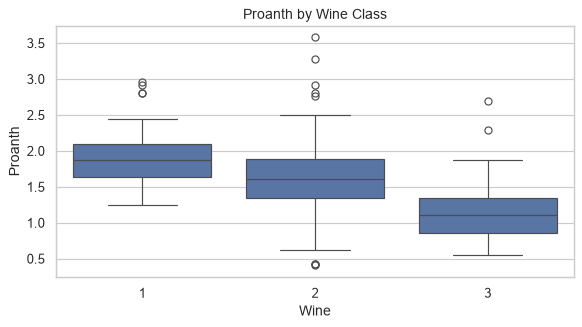

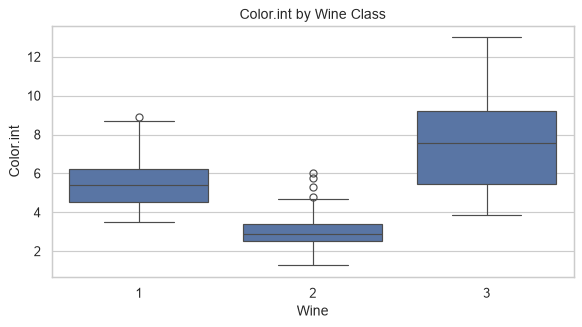

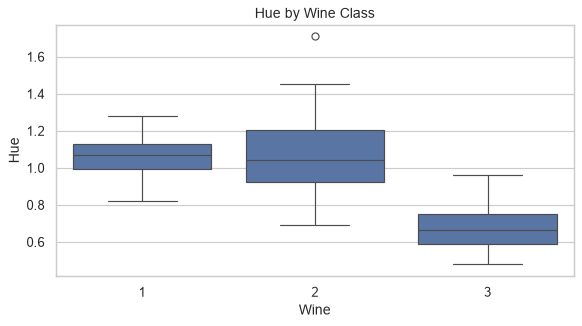

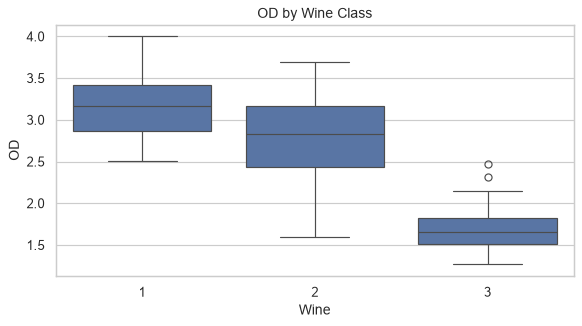

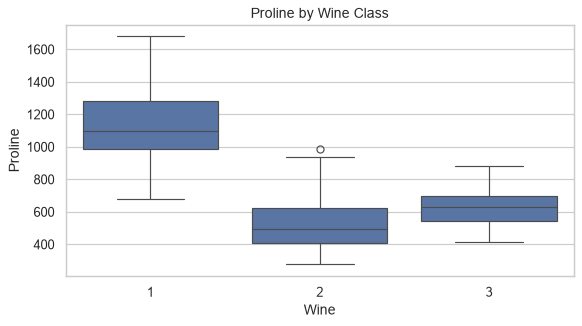

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x=target_col,
        y=col
    )

    plt.title(f"{col} by Wine Class")

    plt.tight_layout()
    plt.show()

## 12. Violin Plot

Violin Plot은 Box Plot과 유사하지만 데이터의 밀도까지 함께 보여줍니다.

그래프가 넓은 부분은 해당 값 근처에 데이터가 많이 존재한다는 의미입니다.


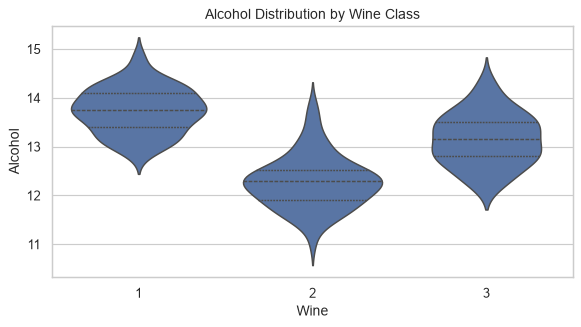

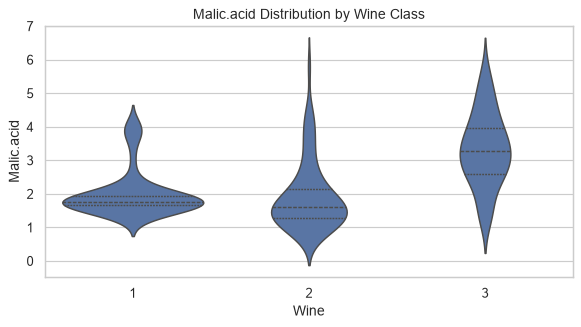

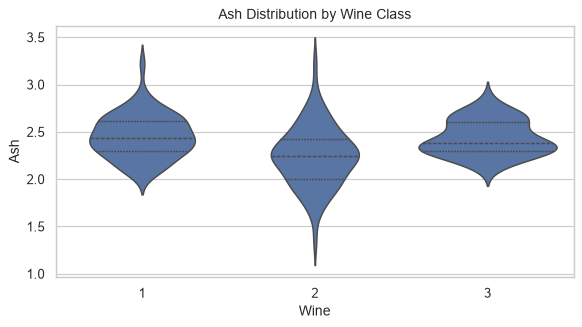

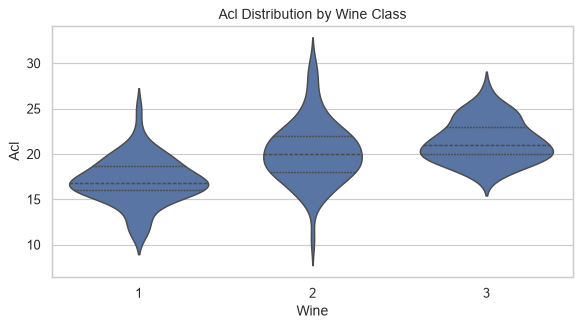

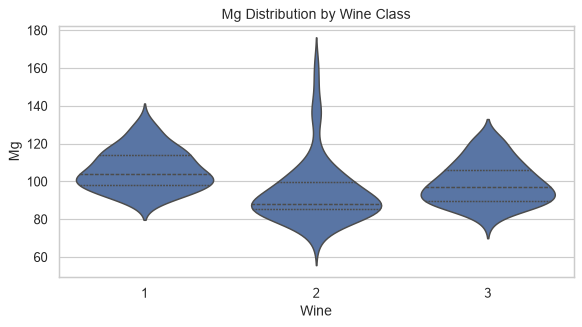

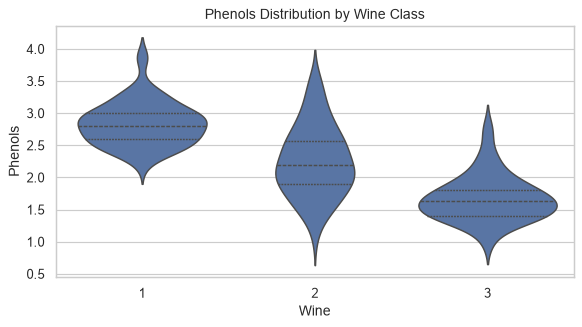

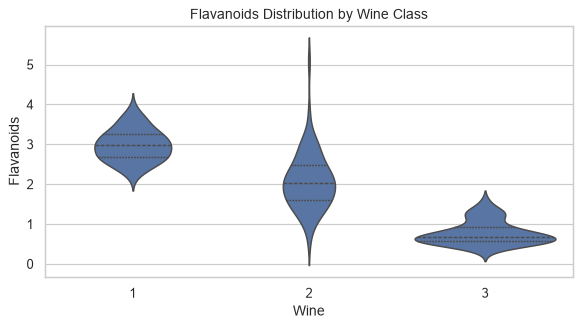

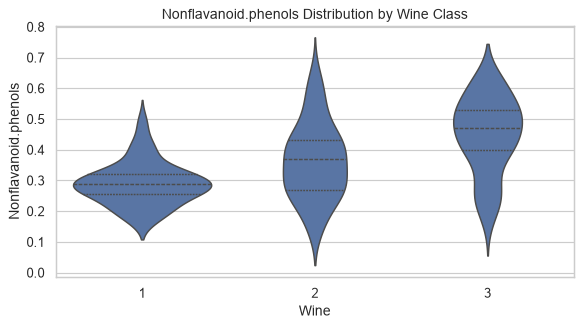

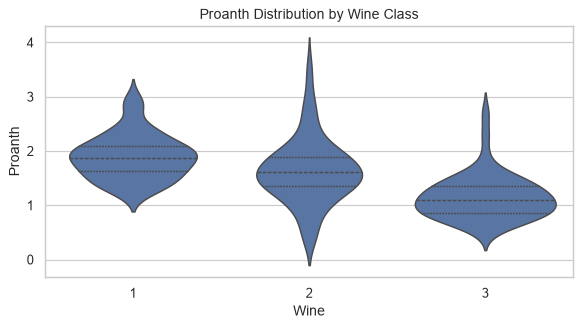

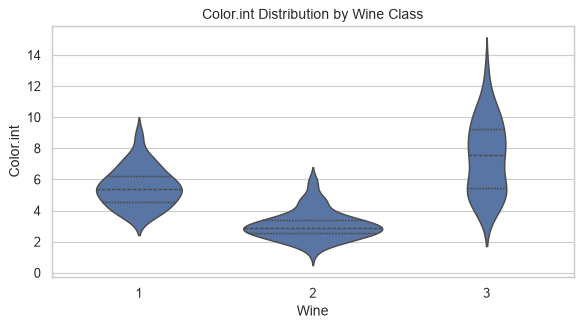

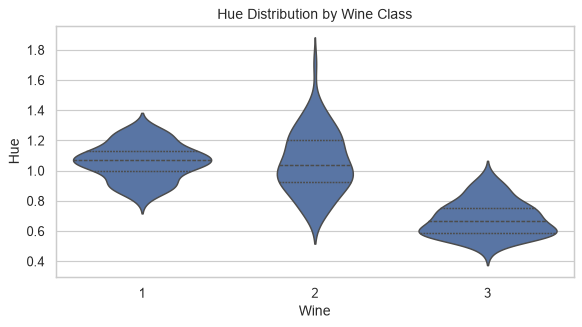

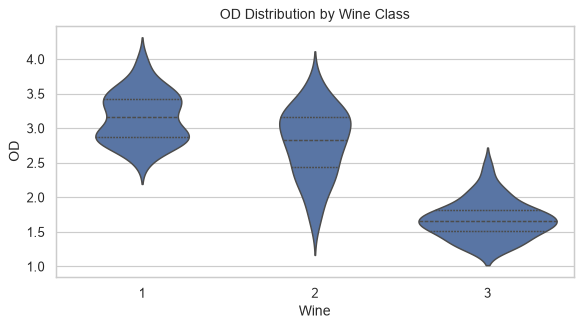

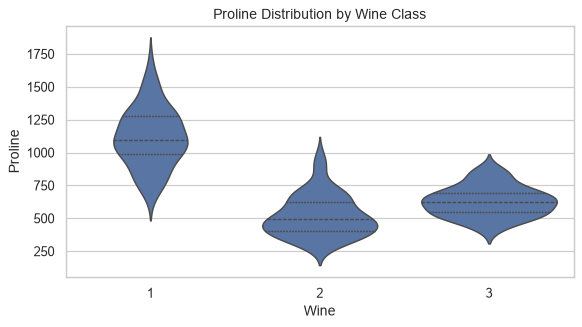

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.violinplot(
        data=df,
        x=target_col,
        y=col,
        inner="quartile"
    )

    plt.title(f"{col} Distribution by Wine Class")

    plt.tight_layout()
    plt.show()

## 13. Pair Plot

Pair Plot은 모든 변수 조합의 관계를 한 번에 보여주는 매우 유용한 EDA 그래프입니다.

색으로 와인 종류을 구분하면 어떤 변수 조합에서 와인 종류이 잘 분리되는지 직관적으로 확인할 수 있습니다.

Wine은 변수가 13개이므로 169개 패널이 생성되어 시간이 걸릴 수 있습니다. 대각선은 변수별 분포, 나머지는 두 변수의 산점도입니다.


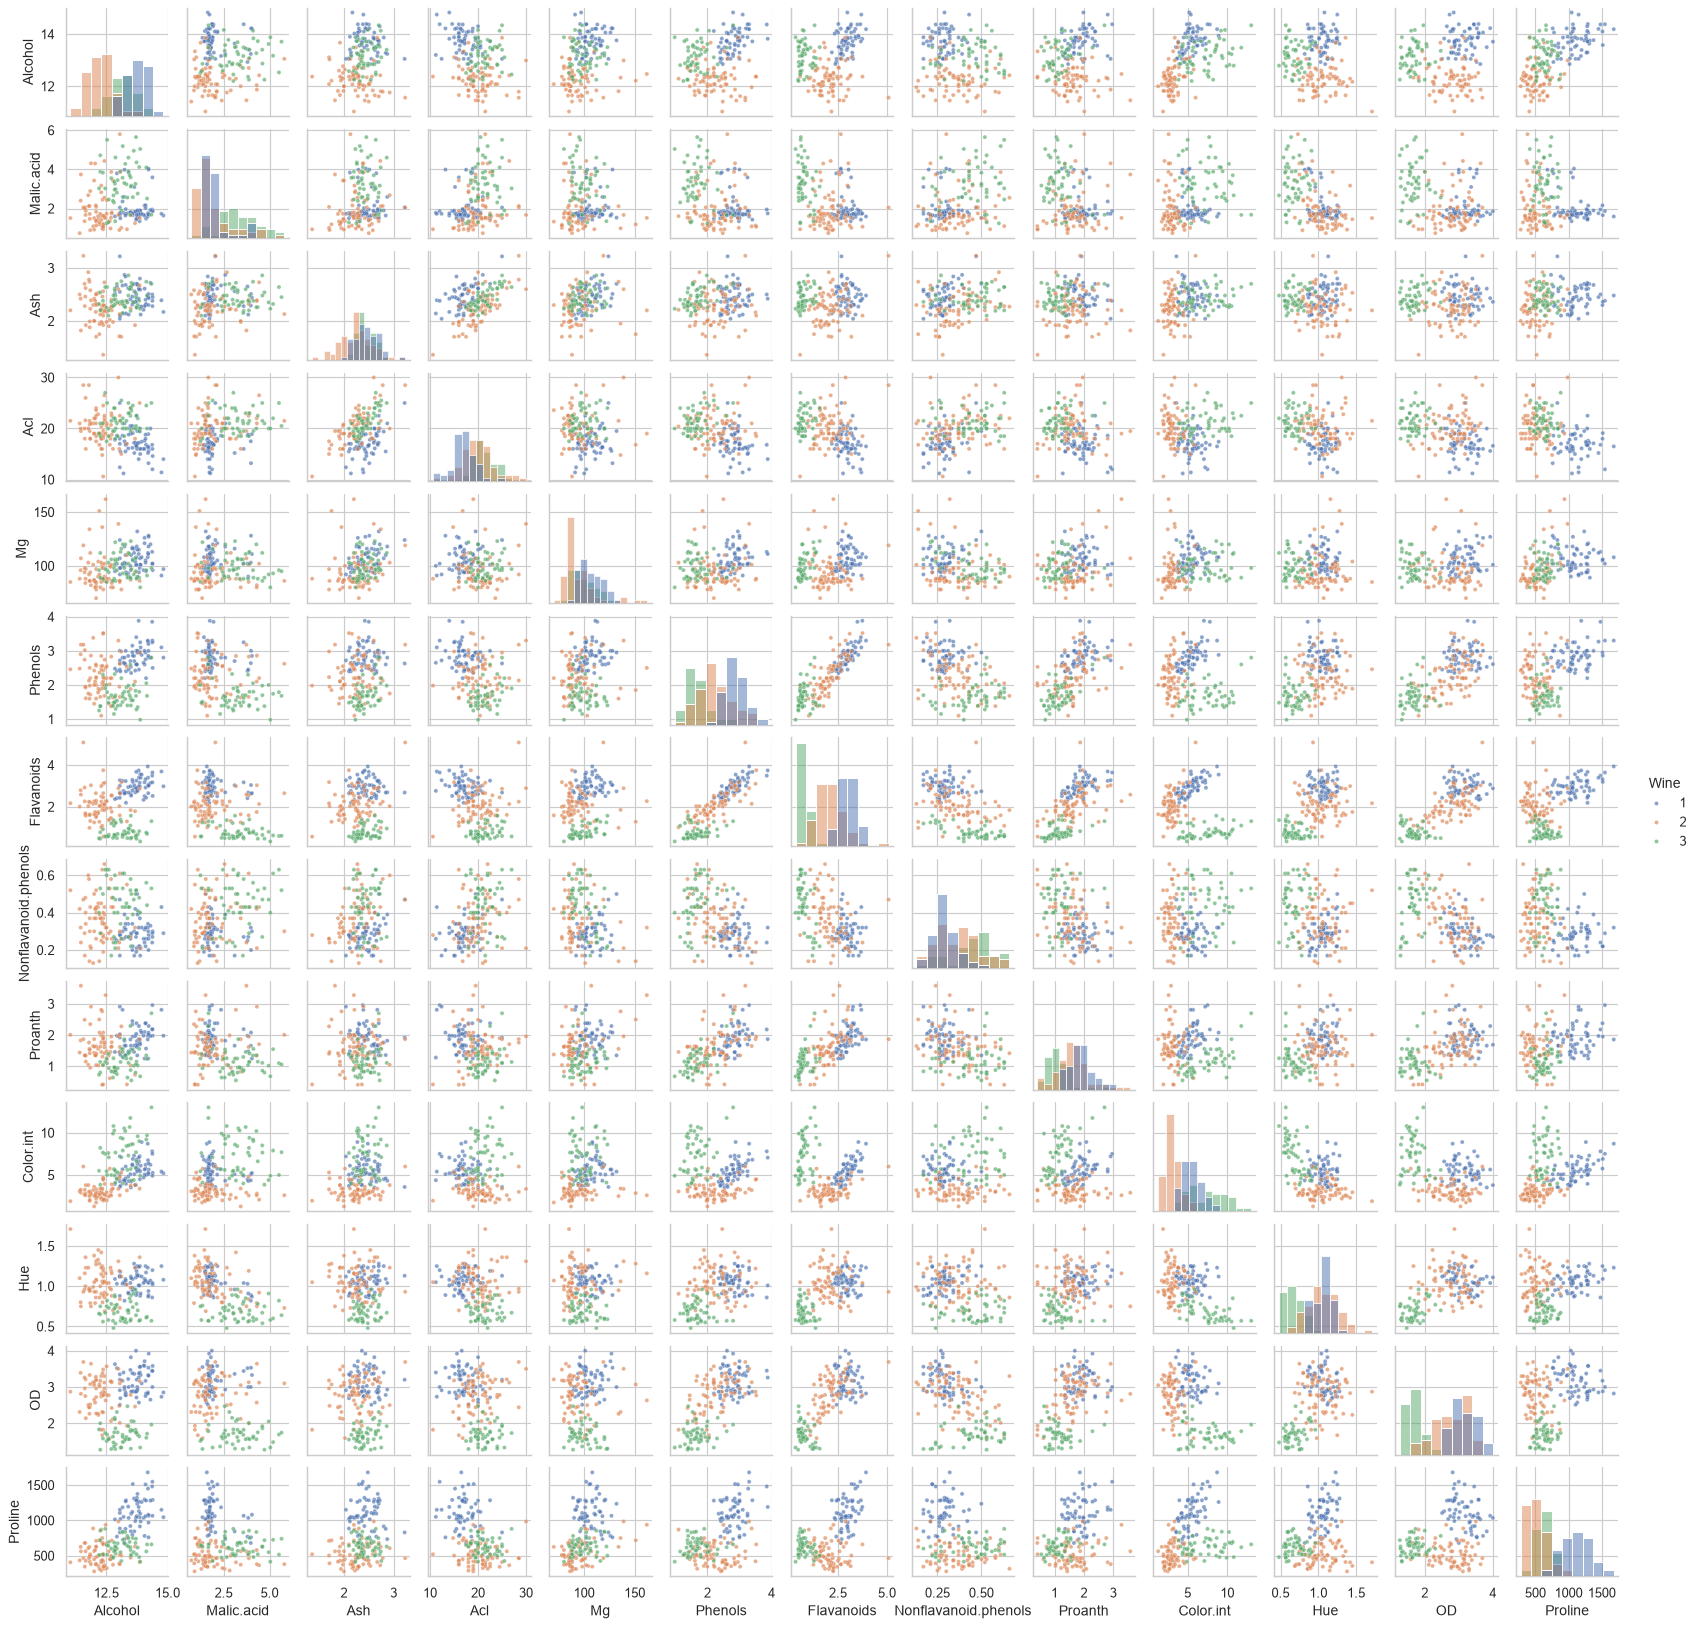

In [ ]:
# 13개 변수이므로 13 × 13 = 169개 패널이 만들어집니다.
sns.pairplot(
    df,
    vars=numeric_cols,
    hue=target_col,
    diag_kind="hist",
    height=1.5,
    plot_kws={"s": 12, "alpha": 0.65}
)

plt.show()

## 14. 변수 간 상관관계 분석

상관계수는 두 변수 사이의 선형적인 관계를 나타냅니다.

- 1에 가까움: 강한 양의 상관관계
- 0에 가까움: 선형적인 관계가 약함
- -1에 가까움: 강한 음의 상관관계

상관관계가 높다고 해서 반드시 인과관계가 있다는 의미는 아닙니다.


In [ ]:
corr = df[numeric_cols].corr()

display(corr.round(3))

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Alcohol,1.000,0.094,0.212,-0.310,0.271,0.289,0.237,-0.156,0.137,0.546,-0.072,0.072,0.644
Malic.acid,0.094,1.000,0.164,0.289,-0.055,-0.335,-0.411,0.293,-0.221,0.249,-0.561,-0.369,-0.192
Ash,0.212,0.164,1.000,0.443,0.287,0.129,0.115,0.186,0.010,0.259,-0.075,0.004,0.224
Acl,-0.310,0.289,0.443,1.000,-0.083,-0.321,-0.351,0.362,-0.197,0.019,-0.274,-0.277,-0.441
Mg,0.271,-0.055,0.287,-0.083,1.000,0.214,0.196,-0.256,0.236,0.200,0.055,0.066,0.393
Phenols,0.289,-0.335,0.129,-0.321,0.214,1.000,0.865,-0.450,0.612,-0.055,0.434,0.700,0.498
Flavanoids,0.237,-0.411,0.115,-0.351,0.196,0.865,1.000,-0.538,0.653,-0.172,0.543,0.787,0.494
Nonflavanoid.phenols,-0.156,0.293,0.186,0.362,-0.256,-0.450,-0.538,1.000,-0.366,0.139,-0.263,-0.503,-0.311
Proanth,0.137,-0.221,0.010,-0.197,0.236,0.612,0.653,-0.366,1.000,-0.025,0.296,0.519,0.330
Color.int,0.546,0.249,0.259,0.019,0.200,-0.055,-0.172,0.139,-0.025,1.000,-0.522,-0.429,0.316


### 상관관계 Heatmap

Heatmap을 이용하면 변수 사이의 상관관계를 색과 숫자로 쉽게 비교할 수 있습니다.


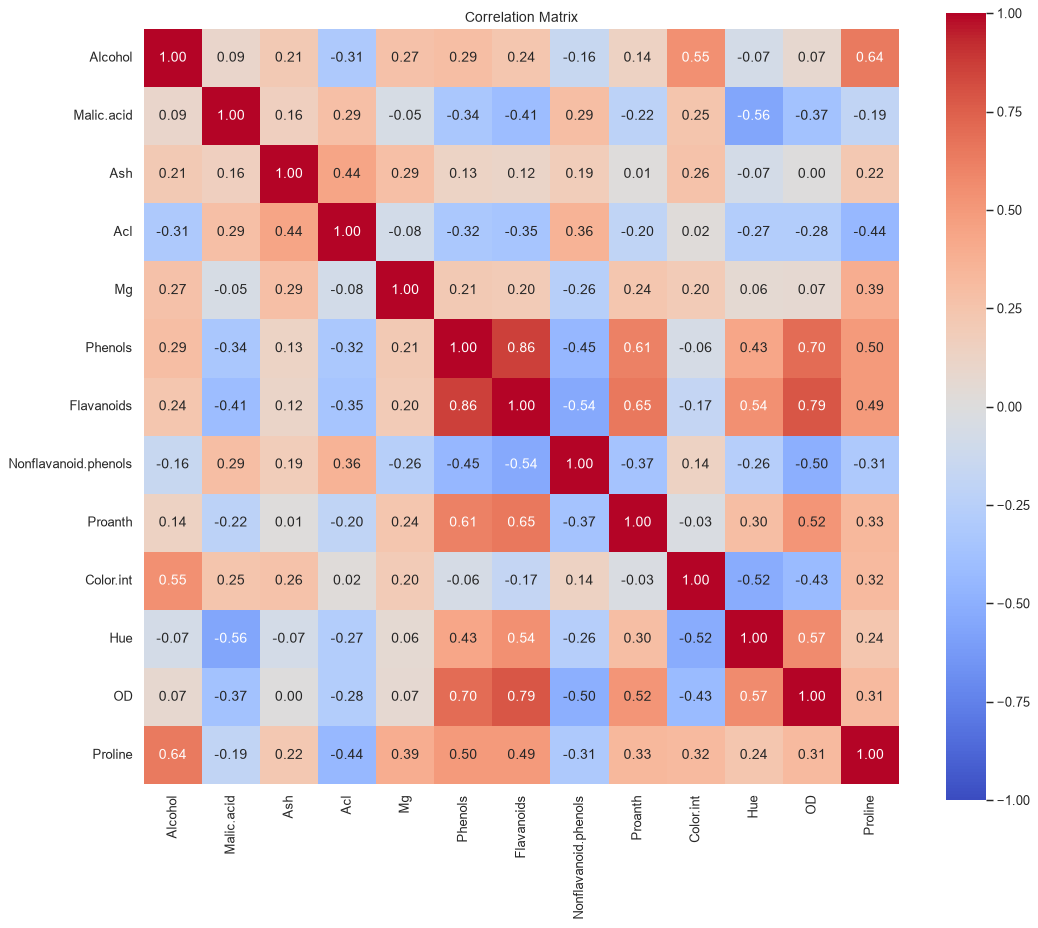

In [ ]:
plt.figure(figsize=(13, 11))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True,
    cmap="coolwarm", center=0, vmin=-1, vmax=1
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## 15. Flavanoids와 OD의 관계

원본의 꽃잎 길이·너비 대신 이 두 측정값을 비교합니다. 점 하나는 와인 샘플이며 색은 와인 종류입니다. 종류별로 점들이 나뉘는지 확인합니다.


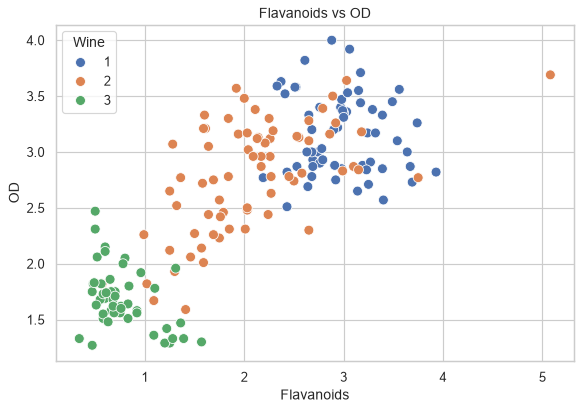

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='Flavanoids',
    y='OD',
    hue=target_col,
    s=70
)

plt.title("Flavanoids vs OD")
plt.xlabel("Flavanoids")
plt.ylabel("OD")

plt.tight_layout()
plt.show()

## 16. Alcohol과 Color.int의 관계

두 번째 산점도는 알코올과 색 강도를 비교합니다. 앞선 산점도와 종류별 겹침 정도를 비교하세요. 이는 탐색용 변수 조합이며 최적 변수 조합이라는 뜻은 아닙니다.


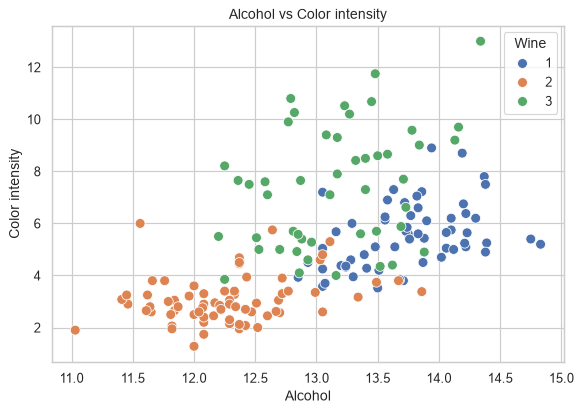

In [ ]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Color.int',
    hue=target_col,
    s=70
)

plt.title("Alcohol vs Color intensity")
plt.xlabel("Alcohol")
plt.ylabel("Color intensity")

plt.tight_layout()
plt.show()

## 17. IQR을 이용한 이상치 탐지

IQR은 3사분위수와 1사분위수의 차이입니다.

`IQR = Q3 - Q1`

일반적으로 다음 범위를 벗어나는 값을 이상치 후보로 판단합니다.

- 하한: `Q1 - 1.5 × IQR`
- 상한: `Q3 + 1.5 × IQR`

이상치로 탐지되었다고 해서 반드시 삭제해야 하는 것은 아닙니다. 실제 오류인지 정상적인 극단값인지 추가 확인이 필요합니다.


In [ ]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        f"{col:20s} : "
        f"{len(outliers)}개 "
        f"(Lower={lower:.2f}, Upper={upper:.2f})"
    )

Alcohol              : 0개 (Lower=10.39, Upper=15.65)
Malic.acid           : 3개 (Lower=-0.62, Upper=5.30)
Ash                  : 3개 (Lower=1.69, Upper=3.08)
Acl                  : 4개 (Lower=10.75, Upper=27.95)
Mg                   : 4개 (Lower=59.50, Upper=135.50)
Phenols              : 0개 (Lower=0.16, Upper=4.39)
Flavanoids           : 0개 (Lower=-1.30, Upper=5.38)
Nonflavanoid.phenols : 0개 (Lower=0.02, Upper=0.69)
Proanth              : 2개 (Lower=0.20, Upper=3.00)
Color.int            : 4개 (Lower=-1.25, Upper=10.67)
Hue                  : 1개 (Lower=0.28, Upper=1.63)
OD                   : 0개 (Lower=0.09, Upper=5.02)
Proline              : 0개 (Lower=-226.25, Upper=1711.75)


### 실제 이상치 데이터 확인

이상치 개수뿐 아니라 어떤 데이터가 이상치 후보인지 직접 확인합니다.


In [ ]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    if len(outliers) > 0:
        print(f"\n[{col} 이상치]")
        display(outliers[[col, target_col]])


[Malic.acid 이상치]

[Ash 이상치]

[Acl 이상치]

[Mg 이상치]

[Proanth 이상치]

[Color.int 이상치]

[Hue 이상치]


,Malic.acid,Wine
123,5.80,2
137,5.51,3
173,5.65,3


,Ash,Wine
25,3.22,1
59,1.36,2
121,3.23,2


,Acl,Wine
59,10.6,2
73,30.0,2
121,28.5,2
127,28.5,2


,Mg,Wine
69,151,2
73,139,2
78,136,2
95,162,2


,Proanth,Wine
95,3.28,2
110,3.58,2


,Color.int,Wine
151,10.80,3
158,13.00,3
159,11.75,3
166,10.68,3


,Hue,Wine
115,1.71,2


## 18. 와인 종류별 평균값 비교

groupby로 종류별 평균을 구하고 melt로 그래프에 사용할 긴 표로 바꿉니다. 변수마다 단위와 크기가 다르므로 Proline처럼 큰 수치를 가진 변수가 그래프를 지배할 수 있습니다. 막대가 크다고 더 중요한 변수라는 뜻은 아닙니다. 동일 변수 안에서 종류별 평균을 비교하세요.


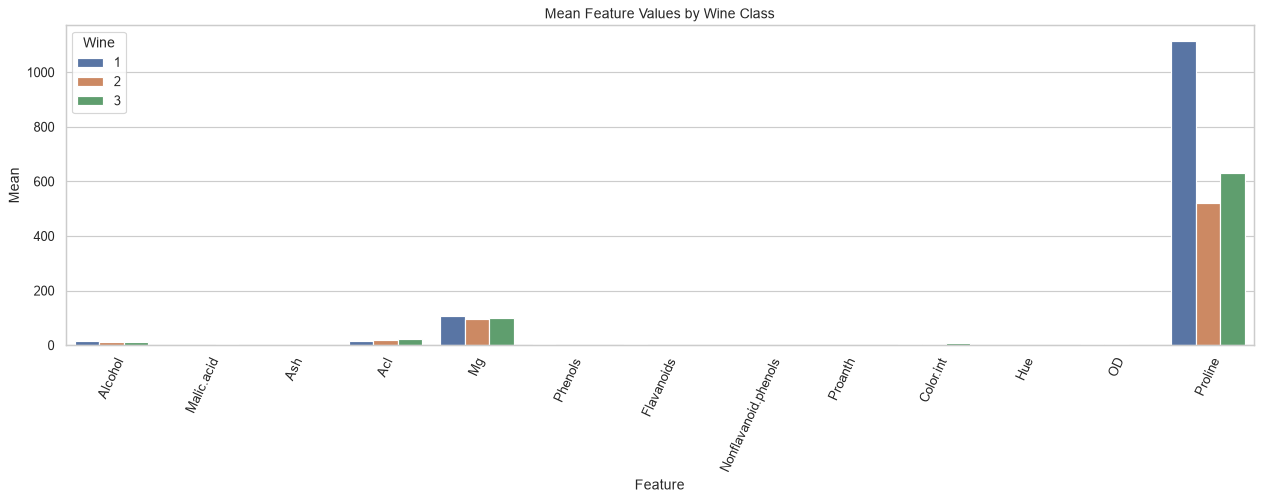

In [ ]:
mean_long = (
    df.groupby(target_col, observed=True)[numeric_cols]
      .mean()
      .reset_index()
      .melt(
          id_vars=target_col,
          var_name="Feature",
          value_name="Mean"
      )
)

plt.figure(figsize=(15, 6))

sns.barplot(
    data=mean_long,
    x="Feature",
    y="Mean",
    hue=target_col
)

plt.title("Mean Feature Values by Wine Class")
plt.xlabel("Feature")
plt.ylabel("Mean")

plt.xticks(rotation=65)

plt.tight_layout()
plt.show()

## 19. EDA 결과 해석

구조 → 품질 → 레이블 → 통계 → 분포 → 종류별 비교 → 상관관계 → 이상치 순서로 확인했습니다.

- 종류별 분포가 덜 겹치는 변수는 무엇인가요?
- 상관관계가 높은 변수들은 무엇인가요? 상관관계는 인과관계를 뜻하지 않습니다.
- 전체 자료 기준 IQR 이상치가 특정 종류의 정상적인 특징일 수 있나요? 이상치를 자동 삭제하지 않습니다.
- 측정 단위가 다른 변수들을 비교할 때 표준화가 필요한가요?

이 노트북은 EDA이며 모델 학습이나 정확도 평가는 포함하지 않습니다.
